# Notebook 3 — Scenario Graph Construction
**Course:** 42578 Advanced Business Analytics (F26), DTU  
**Group 1:** Niklas Petersen, Fabian Mengedoht, Signe Nielsen, Theodor Dornonville de la Cour

---

## Purpose
This notebook bridges **Notebook 2 (Scenario Calibration)** and the upcoming **attack-simulation test environment**.

It:
1. Loads the base grid graph (`grid_graph.pkl`) and the 13 calibrated scenarios
2. Augments the base graph with `_base` attributes required for stochastic factor application
3. Creates one **representative (mean-factor) modified graph** per scenario
4. Runs a **Monte Carlo balance evaluation** (500 draws) per scenario
5. Computes **risk metrics** (P(deficit), EUE, VaR₉₅, CVaR₉₅) per scenario
6. Saves everything to `scenario_graphs.pkl` for the test-environment notebook

### Output format (`scenario_graphs.pkl`)
```python
{
    'S01_high_wind_surplus': {
        'label'          : str,             # human-readable name
        'description'    : str,             # scenario narrative
        'scenario_params': dict,            # factor keys/values
        'graph'          : nx.Graph,        # base graph with mean factors applied
        'mc_results'     : pd.DataFrame,    # 500-row MC draw table
        'risk_metrics'   : dict,            # P_deficit, EUE_mw, VaR_95_mw, CVaR_95_mw …
    },
    # … one entry per scenario
}
```

---

## 1. Imports & Configuration

In [1]:
import pickle
import warnings
from copy import deepcopy
from pathlib import Path

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')

# find grid_graph.pkl - check current dir first, then one level up
# (handles running from repo root vs. running from the notebooks subfolder)
BASE_DIR = None
for _p in [Path('.'), Path('..'), Path(__file__).parent if '__file__' in dir() else Path('.')]:
    if (_p / 'grid_graph.pkl').exists():
        BASE_DIR = _p.resolve()
        break

if BASE_DIR is None:
    raise FileNotFoundError(
        "Couldn't find grid_graph.pkl. Either run this notebook from the "
        "same folder as the data files, or set BASE_DIR manually below."
    )

print(f"Data directory: {BASE_DIR}")

GRID_PKL   = BASE_DIR / 'grid_graph.pkl'
OUTPUT_PKL = BASE_DIR / 'scenario_graphs.pkl'

# MC settings - 500 draws was enough to get stable risk estimates in NB2
N_DRAWS = 500
MC_SEED = 42


Data directory: /Users/niklaspetersen/Desktop/Business Analytics


---
## 2. Load the Base Grid Graph

The base graph (`grid_graph.pkl`) represents the Danish high-voltage transmission network.  
Node types:
- **`generator`** — generation assets (wind, solar, thermal, gas, hydro)
- **`substation`** — demand / load nodes and transmission hubs

We **augment** the graph here by copying current attribute values into `_base` variants.  
This is required by the Monte Carlo sampler (`apply_scenario_to_grid`), which scales from  
the base values rather than modifying in place.

In [2]:
with open(GRID_PKL, 'rb') as f:
    G_base_raw = pickle.load(f)

print(f'loaded: {G_base_raw.number_of_nodes()} nodes, {G_base_raw.number_of_edges()} edges')

# the graph doesnt have _base attributes yet (first version from NB1)
# we need them so we can reset supply/demand between scenarios without
# losing the original values - basically just copying current → baseline
G_base = G_base_raw.copy()

for node, data in G_base.nodes(data=True):
    if 'p_max_base' not in data:
        data['p_max_base'] = data.get('p_max', 0.0)
    if 'demand_base' not in data:
        data['demand_base'] = data.get('demand', 0.0)

for u, v, data in G_base.edges(data=True):
    if 'capacity_base' not in data:
        data['capacity_base'] = data.get('capacity', 0.0)

# quick sanity check
from collections import Counter
print('node types :', dict(Counter(d.get('node_type') for _, d in G_base.nodes(data=True))))
print('gen sources:', dict(Counter(d.get('source')    for _, d in G_base.nodes(data=True))))

total_pmax   = sum(d.get('p_max', 0) for _, d in G_base.nodes(data=True))
total_demand = sum(d.get('demand', 0) for _, d in G_base.nodes(data=True))
print(f'total Pmax: {total_pmax:,.0f} MW  |  total demand: {total_demand:,.0f} MW')


loaded: 631 nodes, 692 edges
node types : {'substation': 261, 'generator': 370}
gen sources: {'substation': 261, 'wind_onshore': 100, 'gas': 96, 'solar': 122, 'wind_offshore': 14, 'thermal': 17, 'hydro': 21}
total Pmax: 15,316 MW  |  total demand: 6,543 MW


---
## 3. Scenario Definitions

All 13 scenarios are defined inline below — no dependency on NB2 or any external file.

In [3]:
# all 13 scenarios defined here - factors calibrated from Energinet 2023 data in NB2
# keeping them inline so this notebook runs standalone
SCENARIO_FALLBACKS = {

    # ── WEATHER & GENERATION SCENARIOS ────────────────────────────────────────

    'S01_high_wind_surplus': {
        'label'               : 'High wind — surplus export',
        'description'         : 'Strong westerly winds. Offshore + onshore wind at ~90% capacity. '
                                'Low demand (weekend night). Grid exporting heavily via all HVDC links. '
                                'Overgeneration risk if any HVDC link fails.',
        'wind_offshore_factor': 0.90,
        'wind_onshore_factor' : 0.85,
        'solar_factor'        : 0.05,
        'thermal_factor'      : 0.20,
        'demand_factor'       : 0.62,
        'hvdc_skagerrak_pct'  : 1.00,
        'hvdc_kontiskan_pct'  : 1.00,
        'hvdc_kontek_pct'     : 1.00,
        'hvdc_cobra_pct'      : 1.00,
        'hvdc_storebelt_pct'  : 1.00,
        'hvdc_viking_pct'     : 1.00,
    },
    'S02_low_wind_import': {
        'label'               : 'Low wind — import dependent',
        'description'         : 'Calm high-pressure system. Wind at ~8% capacity. '
                                'Denmark relying on imports from Norway and Germany. '
                                'Any HVDC cut directly reduces supply adequacy.',
        'wind_offshore_factor': 0.08,
        'wind_onshore_factor' : 0.06,
        'solar_factor'        : 0.25,
        'thermal_factor'      : 0.75,
        'demand_factor'       : 0.88,
        'hvdc_skagerrak_pct'  : 1.00,
        'hvdc_kontiskan_pct'  : 1.00,
        'hvdc_kontek_pct'     : 1.00,
        'hvdc_cobra_pct'      : 1.00,
        'hvdc_storebelt_pct'  : 1.00,
        'hvdc_viking_pct'     : 1.00,
    },
    'S03_high_solar_midday': {
        'label'               : 'High solar — midday duck curve',
        'description'         : 'Clear summer day, solar PV at peak. Low industrial demand midday. '
                                'Classic duck curve — oversupply noon, then evening ramp.',
        'wind_offshore_factor': 0.30,
        'wind_onshore_factor' : 0.25,
        'solar_factor'        : 0.88,
        'thermal_factor'      : 0.25,
        'demand_factor'       : 0.65,
        'hvdc_skagerrak_pct'  : 1.00,
        'hvdc_kontiskan_pct'  : 1.00,
        'hvdc_kontek_pct'     : 1.00,
        'hvdc_cobra_pct'      : 1.00,
        'hvdc_storebelt_pct'  : 1.00,
        'hvdc_viking_pct'     : 1.00,
    },
    'S04_low_renewables_dark': {
        'label'               : 'Dark winter night — low renewables',
        'description'         : 'December, 03:00. No solar. Low wind. Thermal generation '
                                'carrying almost all load. Maximum reliance on CHP plants.',
        'wind_offshore_factor': 0.12,
        'wind_onshore_factor' : 0.10,
        'solar_factor'        : 0.00,
        'thermal_factor'      : 0.85,
        'demand_factor'       : 0.74,
        'hvdc_skagerrak_pct'  : 1.00,
        'hvdc_kontiskan_pct'  : 1.00,
        'hvdc_kontek_pct'     : 1.00,
        'hvdc_cobra_pct'      : 1.00,
        'hvdc_storebelt_pct'  : 1.00,
        'hvdc_viking_pct'     : 1.00,
    },
    'S05_winter_peak_demand': {
        'label'               : 'Winter peak demand',
        'description'         : 'Cold January morning, everyone heating up. '
                                'Highest national consumption of the year (~6 200 MW). '
                                'Tightest supply margin — any generation loss is critical.',
        'wind_offshore_factor': 0.45,
        'wind_onshore_factor' : 0.40,
        'solar_factor'        : 0.00,
        'thermal_factor'      : 0.90,
        'demand_factor'       : 1.00,
        'hvdc_skagerrak_pct'  : 1.00,
        'hvdc_kontiskan_pct'  : 1.00,
        'hvdc_kontek_pct'     : 1.00,
        'hvdc_cobra_pct'      : 1.00,
        'hvdc_storebelt_pct'  : 1.00,
        'hvdc_viking_pct'     : 1.00,
    },
    'S06_summer_trough': {
        'label'               : 'Summer demand trough',
        'description'         : 'August, 03:00, Sunday. Lowest national consumption (~2 500 MW). '
                                'Even modest wind output creates large surplus. '
                                'Grid most prone to overgeneration-triggered instability.',
        'wind_offshore_factor': 0.40,
        'wind_onshore_factor' : 0.35,
        'solar_factor'        : 0.00,
        'thermal_factor'      : 0.15,
        'demand_factor'       : 0.40,
        'hvdc_skagerrak_pct'  : 1.00,
        'hvdc_kontiskan_pct'  : 1.00,
        'hvdc_kontek_pct'     : 1.00,
        'hvdc_cobra_pct'      : 1.00,
        'hvdc_storebelt_pct'  : 1.00,
        'hvdc_viking_pct'     : 1.00,
    },

    # ── INTERCONNECTOR / GEOPOLITICAL SCENARIOS ────────────────────────────────

    'S07_nordic_drought': {
        'label'               : 'Nordic drought — Norway hydro unavailable',
        'description'         : 'Dry year, Norwegian hydro reservoirs critically low. '
                                'Skagerrak export to Norway suspended — Norway is itself importing. '
                                'Denmark loses its largest flexible balancing partner.',
        'wind_offshore_factor': 0.50,
        'wind_onshore_factor' : 0.45,
        'solar_factor'        : 0.10,
        'thermal_factor'      : 0.70,
        'demand_factor'       : 0.88,
        'hvdc_skagerrak_pct'  : 0.00,
        'hvdc_kontiskan_pct'  : 0.30,
        'hvdc_kontek_pct'     : 1.00,
        'hvdc_cobra_pct'      : 1.00,
        'hvdc_storebelt_pct'  : 1.00,
        'hvdc_viking_pct'     : 1.00,
    },
    'S08_german_grid_stress': {
        'label'               : 'German grid stress — limited export south',
        'description'         : 'Germany experiencing its own supply shortage (e.g. Dunkelflaute). '
                                'Kontek cable export restricted; Germany also unable to supply Denmark. '
                                'Northern European grid tighter overall.',
        'wind_offshore_factor': 0.20,
        'wind_onshore_factor' : 0.18,
        'solar_factor'        : 0.05,
        'thermal_factor'      : 0.80,
        'demand_factor'       : 0.95,
        'hvdc_skagerrak_pct'  : 1.00,
        'hvdc_kontiskan_pct'  : 1.00,
        'hvdc_kontek_pct'     : 0.10,
        'hvdc_cobra_pct'      : 1.00,
        'hvdc_storebelt_pct'  : 1.00,
        'hvdc_viking_pct'     : 1.00,
    },
    'S09_cobra_offline': {
        'label'               : 'COBRA cable offline (planned maintenance)',
        'description'         : 'Netherlands interconnector out of service. '
                                'Grid enters attack simulation already missing 700 MW of export capacity. '
                                'High-wind day makes overgeneration likely if any further link is cut.',
        'wind_offshore_factor': 0.75,
        'wind_onshore_factor' : 0.70,
        'solar_factor'        : 0.15,
        'thermal_factor'      : 0.30,
        'demand_factor'       : 0.72,
        'hvdc_skagerrak_pct'  : 1.00,
        'hvdc_kontiskan_pct'  : 1.00,
        'hvdc_kontek_pct'     : 1.00,
        'hvdc_cobra_pct'      : 0.00,
        'hvdc_storebelt_pct'  : 1.00,
        'hvdc_viking_pct'     : 1.00,
    },

    # ── STRESS / COMBINED SCENARIOS ────────────────────────────────────────────

    'S10_storm_day': {
        'label'               : 'Storm day — high wind, derated lines',
        'description'         : 'Gale-force winds. Wind generation at ~95% capacity. '
                                'But overhead transmission lines derated 20% (ice/wind load risk). '
                                'Maximum generation, reduced transmission capacity simultaneously.',
        'wind_offshore_factor': 0.95,
        'wind_onshore_factor' : 0.90,
        'solar_factor'        : 0.00,
        'thermal_factor'      : 0.20,
        'demand_factor'       : 0.80,
        'line_capacity_factor': 0.80,   # overhead lines derated 20%
        'hvdc_skagerrak_pct'  : 0.90,
        'hvdc_kontiskan_pct'  : 0.90,
        'hvdc_kontek_pct'     : 1.00,
        'hvdc_cobra_pct'      : 1.00,
        'hvdc_storebelt_pct'  : 1.00,
        'hvdc_viking_pct'     : 1.00,
    },
    'S11_storebelt_degraded': {
        'label'               : 'Storebælt at 50% — DK1/DK2 weakly coupled',
        'description'         : 'The internal HVDC spine between Western and Eastern Denmark '
                                'operating at half capacity (one pole offline, technical fault). '
                                'DK1 and DK2 become semi-autonomous — tests zone isolation vulnerability.',
        'wind_offshore_factor': 0.55,
        'wind_onshore_factor' : 0.50,
        'solar_factor'        : 0.20,
        'thermal_factor'      : 0.65,
        'demand_factor'       : 0.90,
        'hvdc_skagerrak_pct'  : 1.00,
        'hvdc_kontiskan_pct'  : 1.00,
        'hvdc_kontek_pct'     : 1.00,
        'hvdc_cobra_pct'      : 1.00,
        'hvdc_storebelt_pct'  : 0.50,
        'hvdc_viking_pct'     : 1.00,
    },
    'S12_gas_shortage': {
        'label'               : 'Gas supply disruption — thermal constrained',
        'description'         : 'Gas supply cut or price spike forces thermal CHP plants '
                                'to operate at reduced output. Renewables must carry more load. '
                                'Mirrors 2022-style energy crisis conditions.',
        'wind_offshore_factor': 0.55,
        'wind_onshore_factor' : 0.50,
        'solar_factor'        : 0.10,
        'thermal_factor'      : 0.35,
        'demand_factor'       : 0.92,
        'hvdc_skagerrak_pct'  : 1.00,
        'hvdc_kontiskan_pct'  : 1.00,
        'hvdc_kontek_pct'     : 0.60,
        'hvdc_cobra_pct'      : 1.00,
        'hvdc_storebelt_pct'  : 1.00,
        'hvdc_viking_pct'     : 1.00,
    },
    'S13_second_strike': {
        'label'               : 'Second strike — grid already degraded',
        'description'         : 'A major substation (Endrup 400kV, the highest-betweenness node) '
                                'is already offline from a prior incident. Grid enters the attack '
                                'simulation pre-weakened. Tests residual resilience.',
        'wind_offshore_factor': 0.55,
        'wind_onshore_factor' : 0.50,
        'solar_factor'        : 0.15,
        'thermal_factor'      : 0.70,
        'demand_factor'       : 0.88,
        'hvdc_skagerrak_pct'  : 1.00,
        'hvdc_kontiskan_pct'  : 1.00,
        'hvdc_kontek_pct'     : 1.00,
        'hvdc_cobra_pct'      : 1.00,
        'hvdc_storebelt_pct'  : 1.00,
        'hvdc_viking_pct'     : 1.00,
        'pre_remove_nodes'    : ['sub_27'],   # Endrup 400kV removed before attack starts
    },
}



SCENARIOS = SCENARIO_FALLBACKS

print(f'{len(SCENARIOS)} scenarios loaded')
for sid, s in SCENARIOS.items():
    print(f'  {sid}  →  {s["label"]}')

13 scenarios loaded
  S01_high_wind_surplus  →  High wind — surplus export
  S02_low_wind_import  →  Low wind — import dependent
  S03_high_solar_midday  →  High solar — midday duck curve
  S04_low_renewables_dark  →  Dark winter night — low renewables
  S05_winter_peak_demand  →  Winter peak demand
  S06_summer_trough  →  Summer demand trough
  S07_nordic_drought  →  Nordic drought — Norway hydro unavailable
  S08_german_grid_stress  →  German grid stress — limited export south
  S09_cobra_offline  →  COBRA cable offline (planned maintenance)
  S10_storm_day  →  Storm day — high wind, derated lines
  S11_storebelt_degraded  →  Storebælt at 50% — DK1/DK2 weakly coupled
  S12_gas_shortage  →  Gas supply disruption — thermal constrained
  S13_second_strike  →  Second strike — grid already degraded


## 4. Monte Carlo Sampler (self-contained)

All sampling and grid-application logic lives here — no import from `scenario_sampler.py`.

In [4]:
# MC sampler - all the stochastic sampling logic lives here
# uses correlated Beta distributions so wind offshore/onshore move together,
# demand and thermal are correlated, etc. (makes physical sense)

from scipy.stats import norm

# which factor keys we sample over
FACTOR_KEYS = [
    'wind_offshore_factor', 'wind_onshore_factor', 'solar_factor',
    'thermal_factor', 'demand_factor',
    'hvdc_skagerrak_pct', 'hvdc_kontiskan_pct', 'hvdc_kontek_pct',
    'hvdc_cobra_pct', 'hvdc_storebelt_pct', 'hvdc_viking_pct',
]

# correlation groups - variables in the same group share a latent "weather shock"
CORRELATION_GROUPS = {
    "wind"   : ["wind_offshore_factor", "wind_onshore_factor"],  # move together
    "system" : ["demand_factor", "thermal_factor"],              # cold = high demand + high thermal
    "hvdc"   : ["hvdc_skagerrak_pct", "hvdc_kontiskan_pct",
                "hvdc_kontek_pct", "hvdc_cobra_pct"],
}
CORR_STRENGTH = {"wind": 0.8, "system": 0.6, "hvdc": 0.5}

# slightly higher outage prob for storm scenarios
HVDC_OUTAGE_PROB = {'default': 0.02, 'storm': 0.10, 'cyber': 0.15, 'stress': 0.05}


def _beta_params(mean, sigma):
    # convert mean + std to Beta(a,b) - Beta is bounded [0,1] which is
    # perfect for capacity factors
    if sigma <= 0 or mean <= 0 or mean >= 1:
        return None
    mean = np.clip(mean, 0.01, 0.99)
    var  = min(sigma**2, mean * (1 - mean) * 0.9)
    d    = mean * (1 - mean) / var - 1
    return mean * d, (1 - mean) * d

def _sample_beta(rng, mean, sigma):
    p = _beta_params(mean, sigma)
    return float(rng.beta(*p)) if p else float(mean)

def _generate_latent(rng, keys):
    # gaussian copula idea: each group shares a "weather shock"
    # then each variable gets its own idiosyncratic noise on top
    latent = {}
    for group, group_keys in CORRELATION_GROUPS.items():
        z_shared = rng.normal()
        s = CORR_STRENGTH[group]
        for key in group_keys:
            if key in keys:
                latent[key] = s * z_shared + np.sqrt(1 - s**2) * rng.normal()
    for key in keys:
        if key not in latent:
            latent[key] = rng.normal()
    return latent

def _hvdc_outage_prob(scenario_id):
    if 'storm' in scenario_id:  return HVDC_OUTAGE_PROB['storm']
    if 'cyber' in scenario_id:  return HVDC_OUTAGE_PROB['cyber']
    if 'stress' in scenario_id: return HVDC_OUTAGE_PROB['stress']
    return HVDC_OUTAGE_PROB['default']

def _apply_tail_risk(rng, value, prob=0.1):
    # 10% chance of a really bad draw - adds fat tails to the distribution
    return value * rng.uniform(0.5, 0.8) if rng.random() < prob else value


def apply_scenario_to_grid(G, draw):
    # takes a factor dict and returns a modified copy of the graph
    # with supply/demand/capacity scaled accordingly
    # note: gas nodes are left at 100% - no gas_factor in current scenarios
    # (TODO: add gas_factor for S12 gas shortage if needed later)
    G2 = G.copy()

    for n, data in G2.nodes(data=True):
        src = data.get("source", "")
        if   "wind_offshore" in src: f = draw.get("wind_offshore_factor", 1)
        elif "wind_onshore"  in src: f = draw.get("wind_onshore_factor",  1)
        elif "solar"         in src: f = draw.get("solar_factor",         1)
        elif "thermal"       in src: f = draw.get("thermal_factor",       1)
        else:                        f = 1  # gas / hydro / substation unchanged

        if "p_max_base" in data:
            p_max = data["p_max_base"]
            data["supply"] = max(data.get("p_min", 0), min(p_max * f, p_max))

        if "demand_base" in data:
            data["demand"] = data["demand_base"] * draw.get("demand_factor", 1)

    for u, v, data in G2.edges(data=True):
        name = data.get("name", "").lower()
        if   "kontek"    in name: f = draw.get("hvdc_kontek_pct",    1)
        elif "cobra"     in name: f = draw.get("hvdc_cobra_pct",     1)
        elif "storebelt" in name or "storebælt" in name:
                                  f = draw.get("hvdc_storebelt_pct", 1)
        elif "skagerrak" in name: f = draw.get("hvdc_skagerrak_pct", 1)
        elif "kontiskan" in name: f = draw.get("hvdc_kontiskan_pct", 1)
        elif "viking"    in name: f = draw.get("hvdc_viking_pct",    1)
        else:                     f = 1
        if "capacity_base" in data:
            data["capacity"] = data["capacity_base"] * f

    return G2


def sample_scenario(scenario_id, scenarios, sigmas, n=500, seed=42):
    # draw n stochastic realisations of a scenario
    rng  = np.random.default_rng(seed)
    base = scenarios[scenario_id]
    sigma_map = sigmas.get(scenario_id, {})
    draws = []

    for i in range(n):
        draw = deepcopy(base)
        draw["_mc_trial"] = i
        latent = _generate_latent(rng, FACTOR_KEYS)

        for key in FACTOR_KEYS:
            if key not in base: continue
            mean  = base[key]
            sigma = sigma_map.get(key, 0.0)

            if sigma == 0 or mean == 0:
                draw[key] = mean
                continue

            if key.startswith("hvdc"):
                # HVDC is either fully out (rare) or running with some derating
                val = (0.0 if rng.random() < _hvdc_outage_prob(scenario_id)
                       else _sample_beta(rng, mean, sigma))
            else:
                val = _sample_beta(rng, mean, sigma)

            draw[key] = _apply_tail_risk(rng, val)

        draws.append(draw)
    return draws


def run_mc(draws, G, eval_func):
    # run each draw through the eval function and collect results
    records = []
    for draw in draws:
        G_state = apply_scenario_to_grid(G, draw)
        metrics = eval_func(G_state)
        metrics["_mc_trial"] = draw["_mc_trial"]
        records.append(metrics)
    return pd.DataFrame(records)


print("sampler ready")


sampler ready


---
## 5. Apply Scenarios to the Grid

For each scenario we produce **two** things:

1. **Representative graph** — the scenario's mean factor values applied deterministically.  
   This is what the test-environment notebook will use as the starting graph for attack simulation.

2. **Monte Carlo draws** — 500 stochastic realisations (correlated Beta sampling + HVDC outage model)  
   used to estimate supply/demand balance distributions and risk metrics.

### Source → Factor mapping

| Node `source` field | Factor applied |
|---|---|
| `wind_offshore` | `wind_offshore_factor` |
| `wind_onshore` | `wind_onshore_factor` |
| `solar` | `solar_factor` |
| `thermal` | `thermal_factor` |
| `gas` | **factor = 1.0** — gas is dispatchable; not explicitly scaled in current scenarios |
| `hydro` | factor = 1.0 — unchanged |

> **Design note:** The representative graph uses `apply_scenario_to_grid` from `scenario_sampler.py` directly,
> so it is guaranteed to be **consistent with the MC runs**.
> Gas currently runs at 100% capacity; add a `gas_factor` key to scenarios + sampler when S12 needs it.
| `substation` | `demand_factor` applied to `demand` |

> **Note:** HVDC interconnectors are not yet modelled as edges in this version of  
> `grid_graph.pkl`. HVDC factor keys are stored in the scenario params and  
> will be applied automatically once HVDC edges are added to the graph.

In [5]:
# keys we actually pass to apply_scenario_to_grid
_FACTOR_KEYS = [
    'wind_offshore_factor', 'wind_onshore_factor', 'solar_factor',
    'thermal_factor', 'demand_factor',
    'hvdc_skagerrak_pct', 'hvdc_kontiskan_pct', 'hvdc_kontek_pct',
    'hvdc_cobra_pct', 'hvdc_storebelt_pct', 'hvdc_viking_pct',
]


def apply_scenario_mean(G, scenario):
    # builds a "mean draw" using the scenario's point estimates and runs it
    # through the same function the MC uses - so the representative graph
    # is guaranteed to match what the MC draws look like on average
    mean_draw = {k: scenario.get(k, 1.0) for k in _FACTOR_KEYS}
    mean_draw['_mc_trial'] = -1
    G2 = apply_scenario_to_grid(G, mean_draw)

    # S10 storm day: overhead lines derate 20% due to ice/wind load
    line_f = scenario.get('line_capacity_factor', 1.0)
    if line_f != 1.0:
        for u, v, data in G2.edges(data=True):
            if data.get('edge_type') == 'transmission' and data.get('capacity_base', 0) > 0:
                data['capacity'] = data['capacity_base'] * line_f

    # S13 second strike: one major substation already knocked out before we start
    for node_id in scenario.get('pre_remove_nodes', []):
        if G2.has_node(node_id):
            G2.remove_node(node_id)
            print(f'  removed {node_id} ({scenario.get("label", "")})')
        else:
            print(f'  WARNING: {node_id} not found in graph - check node IDs')

    return G2


# build one representative graph per scenario
print('building scenario graphs...')
scenario_graphs = {}

for sid, scenario in SCENARIOS.items():
    G_scen = apply_scenario_mean(G_base, scenario)
    scenario_graphs[sid] = G_scen

    supply  = sum(d.get('supply', 0) for _, d in G_scen.nodes(data=True) if d.get('node_type') == 'generator')
    demand  = sum(d.get('demand', 0) for _, d in G_scen.nodes(data=True) if d.get('node_type') == 'substation')
    print(f'  {sid:<32}  supply={supply:,.0f} MW  demand={demand:,.0f} MW  balance={supply-demand:+,.0f} MW')

print(f'\ndone - {len(scenario_graphs)} graphs built')


building scenario graphs...
  S01_high_wind_surplus             supply=5,839 MW  demand=4,057 MW  balance=+1,783 MW
  S02_low_wind_import               supply=2,974 MW  demand=5,758 MW  balance=-2,784 MW
  S03_high_solar_midday             supply=3,680 MW  demand=4,253 MW  balance=-573 MW
  S04_low_renewables_dark           supply=3,120 MW  demand=4,842 MW  balance=-1,722 MW
  S05_winter_peak_demand            supply=4,519 MW  demand=6,543 MW  balance=-2,024 MW
  S06_summer_trough                 supply=3,585 MW  demand=2,617 MW  balance=+968 MW
  S07_nordic_drought                supply=4,596 MW  demand=5,758 MW  balance=-1,162 MW
  S08_german_grid_stress            supply=3,446 MW  demand=6,216 MW  balance=-2,770 MW
  S09_cobra_offline                 supply=5,330 MW  demand=4,711 MW  balance=+619 MW
  S10_storm_day                     supply=6,033 MW  demand=5,235 MW  balance=+798 MW
  S11_storebelt_degraded            supply=4,816 MW  demand=5,889 MW  balance=-1,073 MW
  S12_gas_sh

---
## 6. Monte Carlo Balance Evaluation

We run 500 stochastic draws per scenario using the correlated Beta sampler from NB2.  
For each draw, supply and demand are computed across the whole graph and split by zone (DK1 / DK2).

In [6]:
def eval_grid_balance(G_state):
    # compute national + zonal supply/demand for one MC draw
    supply = dk1_s = dk2_s = 0.0
    demand = dk1_d = dk2_d = 0.0

    for _, d in G_state.nodes(data=True):
        ntype = d.get('node_type', '')
        area  = d.get('area', '')

        if ntype == 'generator':
            s = d.get('supply', 0.0)
            supply += s
            if area == 'DK1':   dk1_s += s
            elif area == 'DK2': dk2_s += s

        elif ntype == 'substation':
            dem = d.get('demand', 0.0)
            demand += dem
            if area == 'DK1':   dk1_d += dem
            elif area == 'DK2': dk2_d += dem

    bal = supply - demand
    return {
        'supply_mw'     : supply,
        'demand_mw'     : demand,
        'balance_mw'    : bal,
        'deficit_mw'    : max(0.0, -bal),   # how short are we?
        'surplus_mw'    : max(0.0,  bal),   # how much are we overproducing?
        'dk1_balance_mw': dk1_s - dk1_d,
        'dk2_balance_mw': dk2_s - dk2_d,
        'dk1_supply_mw' : dk1_s,
        'dk1_demand_mw' : dk1_d,
        'dk2_supply_mw' : dk2_s,
        'dk2_demand_mw' : dk2_d,
    }


# uncertainty widths for each factor - same as NB2
DEFAULT_SIGMAS = {
    'wind_offshore_factor': 0.12,
    'wind_onshore_factor' : 0.10,
    'solar_factor'        : 0.15,  # solar is quite variable
    'thermal_factor'      : 0.08,
    'demand_factor'       : 0.05,
    'hvdc_skagerrak_pct'  : 0.05,
    'hvdc_kontiskan_pct'  : 0.05,
    'hvdc_kontek_pct'     : 0.05,
    'hvdc_cobra_pct'      : 0.05,
    'hvdc_storebelt_pct'  : 0.05,
    'hvdc_viking_pct'     : 0.05,
}

# zero sigma for anything already at 0 - no point sampling around zero
SIGMAS = {
    sid: {k: (0.0 if SCENARIOS[sid].get(k, 1.0) == 0.0 else DEFAULT_SIGMAS.get(k, 0.0))
          for k in DEFAULT_SIGMAS}
    for sid in SCENARIOS
}


print(f'running MC: {N_DRAWS} draws × {len(SCENARIOS)} scenarios ({N_DRAWS * len(SCENARIOS):,} total)')
print('─' * 55)

mc_results = {}

for sid in SCENARIOS:
    draws = sample_scenario(sid, SCENARIOS, SIGMAS, n=N_DRAWS, seed=MC_SEED)
    df    = run_mc(draws, G_base, eval_grid_balance)
    df['_scenario_id'] = sid
    mc_results[sid] = df
    print(f'  {sid:<32} done')

print('─' * 55)
print('finished')


running MC: 500 draws × 13 scenarios (6,500 total)
───────────────────────────────────────────────────────
  S01_high_wind_surplus            done
  S02_low_wind_import              done
  S03_high_solar_midday            done
  S04_low_renewables_dark          done
  S05_winter_peak_demand           done
  S06_summer_trough                done
  S07_nordic_drought               done
  S08_german_grid_stress           done
  S09_cobra_offline                done
  S10_storm_day                    done
  S11_storebelt_degraded           done
  S12_gas_shortage                 done
  S13_second_strike                done
───────────────────────────────────────────────────────
finished


---
## 7. Risk Metrics

For each scenario we compute:

| Metric | Meaning |
|---|---|
| **Median balance** | Typical supply − demand (MW) |
| **P(deficit)** | Fraction of draws with supply < demand |
| **EUE** | Expected Unserved Energy — average deficit across all draws (MW) |
| **VaR₉₅** | 95th-percentile deficit: worst outcome in 95% of scenarios |
| **CVaR₉₅** | Conditional VaR: mean deficit in worst 5% of draws |

In [7]:
def compute_risk_metrics(df):
    deficits = df['deficit_mw']
    balance  = df['balance_mw']

    var_95  = deficits.quantile(0.95)
    # CVaR = average of the worst 5% of draws
    cvar_95 = deficits[deficits >= var_95].mean() if (deficits >= var_95).any() else 0.0

    return {
        'median_balance_mw' : round(balance.median(), 1),
        'mean_balance_mw'   : round(balance.mean(),   1),
        'P_deficit'         : round((deficits > 0).mean(), 4),
        'EUE_mw'            : round(deficits.mean(), 1),   # expected unserved energy
        'VaR_95_mw'         : round(var_95,  1),
        'CVaR_95_mw'        : round(cvar_95, 1),
        'max_deficit_mw'    : round(deficits.max(), 1),
        'pct_surplus_draws' : round((balance > 0).mean(), 4),
    }


risk_metrics = {sid: compute_risk_metrics(df) for sid, df in mc_results.items()}

rows = []
for sid, m in risk_metrics.items():
    rows.append({
        'Scenario'         : sid[:3],
        'Label'            : SCENARIOS[sid]['label'],
        'Median bal. (MW)' : m['median_balance_mw'],
        'P(deficit)'       : f"{m['P_deficit']:.1%}",
        'EUE (MW)'         : m['EUE_mw'],
        'VaR95 (MW)'       : m['VaR_95_mw'],
        'CVaR95 (MW)'      : m['CVaR_95_mw'],
    })

risk_df = pd.DataFrame(rows).set_index('Scenario')
risk_df_sorted = risk_df.sort_values('EUE (MW)', ascending=False)

print('Scenario Risk Metrics — sorted by EUE (most at-risk first)')
print('─' * 85)
print(risk_df_sorted.to_string())
print()
print(f'most stressed : {risk_df_sorted.index[0]}')
print(f'least stressed: {risk_df_sorted.index[-1]}')


Scenario Risk Metrics — sorted by EUE (most at-risk first)
─────────────────────────────────────────────────────────────────────────────────────
                                                Label  Median bal. (MW) P(deficit)  EUE (MW)  VaR95 (MW)  CVaR95 (MW)
Scenario                                                                                                             
S02                       Low wind — import dependent           -2859.9      98.8%    2664.4      3430.3       3541.7
S08         German grid stress — limited export south           -2801.2      98.0%    2608.6      3517.5       3637.2
S05                                Winter peak demand           -2077.7      94.6%    1952.9      2739.1       2877.4
S04                Dark winter night — low renewables           -1650.9      95.0%    1553.4      2426.7       2595.6
S12       Gas supply disruption — thermal constrained           -1616.2      93.8%    1514.1      2444.8       2701.7
S07         Nordic drought — 

---
## 8. Visualisations

### 8a. Grid Balance Distribution per Scenario

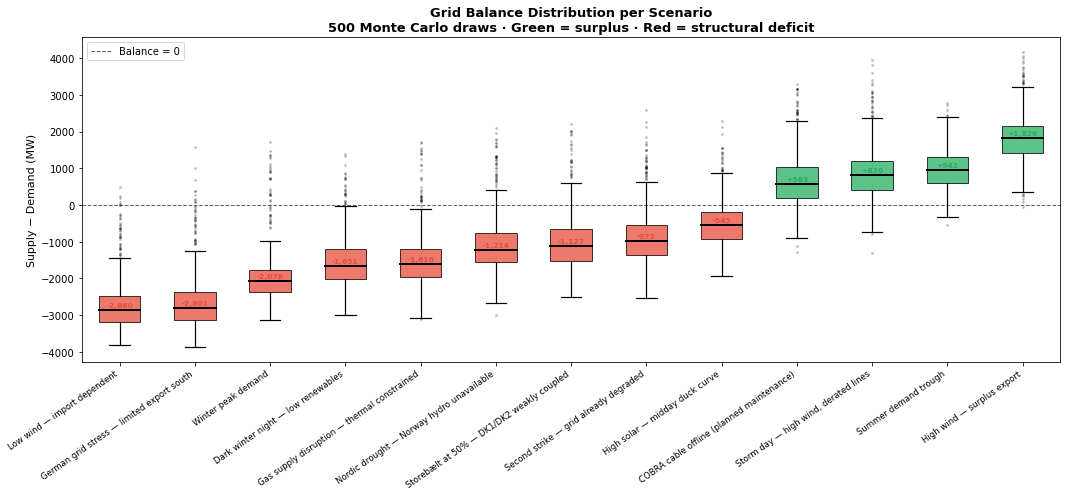

In [8]:
sorted_sids = sorted(mc_results, key=lambda s: mc_results[s]['balance_mw'].median())
labels       = [SCENARIOS[s]['label'] for s in sorted_sids]
balance_data = [mc_results[s]['balance_mw'].values for s in sorted_sids]
medians      = [mc_results[s]['balance_mw'].median() for s in sorted_sids]
box_colors   = ['#e74c3c' if m < 0 else '#27ae60' for m in medians]

fig, ax = plt.subplots(figsize=(15, 7))
bp = ax.boxplot(
    balance_data, vert=True, patch_artist=True,
    medianprops=dict(color='black', linewidth=2),
    whiskerprops=dict(linewidth=1.2), capprops=dict(linewidth=1.2),
    flierprops=dict(marker='.', markersize=3, alpha=0.3), widths=0.55,
)
for patch, color in zip(bp['boxes'], box_colors):
    patch.set_facecolor(color); patch.set_alpha(0.75)

ax.axhline(0, color='black', linewidth=1.0, linestyle='--', alpha=0.6, label='Balance = 0')
ax.set_xticks(range(1, len(sorted_sids) + 1))
ax.set_xticklabels(labels, rotation=35, ha='right', fontsize=8.5)
ax.set_ylabel('Supply − Demand (MW)', fontsize=11)
ax.set_title(
    'Grid Balance Distribution per Scenario\n'
    f'{N_DRAWS} Monte Carlo draws · Green = surplus · Red = structural deficit',
    fontsize=13, fontweight='bold'
)
for i, (m, c) in enumerate(zip(medians, box_colors)):
    ax.text(i + 1, m + 50, f'{m:+,.0f}', ha='center', va='bottom', fontsize=7.5, color=c, fontweight='bold')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

### 8b. Scenario Factor Heat-map

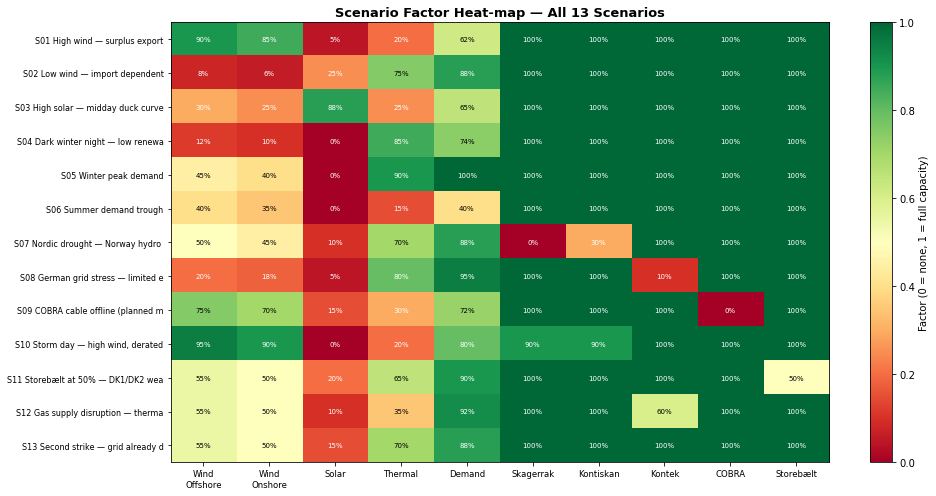

In [9]:
factor_cols = [
    'wind_offshore_factor', 'wind_onshore_factor', 'solar_factor',
    'thermal_factor', 'demand_factor',
    'hvdc_skagerrak_pct', 'hvdc_kontiskan_pct', 'hvdc_kontek_pct',
    'hvdc_cobra_pct', 'hvdc_storebelt_pct',
]
col_labels = [
    'Wind\nOffshore', 'Wind\nOnshore', 'Solar', 'Thermal', 'Demand',
    'Skagerrak', 'Kontiskan', 'Kontek', 'COBRA', 'Storebælt',
]

heat_rows = []
row_labels = []
for sid, s in SCENARIOS.items():
    heat_rows.append([s.get(c, 1.0) for c in factor_cols])
    row_labels.append(f"{sid[:3]} {s['label'][:30]}")

heat_arr = np.array(heat_rows)

fig, ax = plt.subplots(figsize=(14, 7))
im = ax.imshow(heat_arr, cmap='RdYlGn', vmin=0, vmax=1, aspect='auto')

ax.set_xticks(range(len(col_labels)))
ax.set_xticklabels(col_labels, fontsize=8.5, ha='center')
ax.set_yticks(range(len(row_labels)))
ax.set_yticklabels(row_labels, fontsize=8)

# Annotate each cell
for i in range(heat_arr.shape[0]):
    for j in range(heat_arr.shape[1]):
        val = heat_arr[i, j]
        ax.text(j, i, f'{val:.0%}', ha='center', va='center', fontsize=7,
                color='black' if 0.3 < val < 0.8 else 'white')

plt.colorbar(im, ax=ax, label='Factor (0 = none, 1 = full capacity)')
ax.set_title('Scenario Factor Heat-map — All 13 Scenarios', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 8c. Node Removal Attack Surface Preview

Ranks substation nodes by **degree centrality** — the highest-degree substations are the most  
connected and therefore the highest-priority targets for both node- and edge-removal attacks.  
This gives the test-environment builder a quick reference for where to start.

In [10]:
# compute centrality on the base graph (not scenario-specific)
# betweenness = how often a node sits on shortest paths between others
# high betweenness = removing it disconnects a lot of the network
degree_centrality      = nx.degree_centrality(G_base)
betweenness_centrality = nx.betweenness_centrality(G_base, normalized=True)

rows = []
for node, data in G_base.nodes(data=True):
    if data.get('node_type') == 'substation':
        rows.append({
            'node_id'   : node,
            'name'      : data.get('name', ''),
            'area'      : data.get('area', ''),
            'voltage_kv': data.get('voltage_kv', 0),
            'demand_mw' : round(data.get('demand', 0), 1),
            'degree'    : G_base.degree(node),
            'betweenness': round(betweenness_centrality[node], 4),
        })

centrality_df = (
    pd.DataFrame(rows)
    .sort_values('betweenness', ascending=False)
    .reset_index(drop=True)
)

print('top 15 substations by betweenness (= highest priority attack targets)')
print('─' * 70)
print(centrality_df.head(15).to_string(index=False))


top 15 substations by betweenness (= highest priority attack targets)
──────────────────────────────────────────────────────────────────────
node_id         name area  voltage_kv  demand_mw  degree  betweenness
sub_305  TAN_150_SK1  DK1       165.0       26.0       7       0.0804
sub_236 HER_150_NORD  DK1       165.0       26.0       8       0.0774
sub_182    VEJ_132_F  DK2       132.0       19.6       9       0.0772
sub_311   TJE_150_S1  DK1       165.0       26.0       4       0.0707
sub_276   MOSV150_S1  DK1       165.0       26.0       8       0.0688
sub_125    KAM_132_F  DK2       132.0       19.6       8       0.0686
sub_321   TRI_150_S1  DK1       165.0       26.0       9       0.0649
sub_171    SPA_132_F  DK2       132.0       19.6       9       0.0621
sub_260   LAG_150_S1  DK1       165.0       26.0       5       0.0618
sub_259   KNA_150_S1  DK1       165.0       26.0       7       0.0592
sub_206   BJH_150_S1  DK1       165.0       26.0       6       0.0521
sub_116    HVE_132_

In [11]:
# top transmission lines by capacity - these are the most impactful edge removals
edge_rows = []
for u, v, data in G_base.edges(data=True):
    if data.get('edge_type') == 'transmission':
        edge_rows.append({
            'edge'       : f'{u} — {v}',
            'name'       : data.get('name', ''),
            'capacity_mw': round(data.get('capacity', 0), 1),
        })

edge_df = (
    pd.DataFrame(edge_rows)
    .sort_values('capacity_mw', ascending=False)
    .reset_index(drop=True)
)

print('top 15 transmission edges by capacity')
print('─' * 60)
print(edge_df.head(15).to_string(index=False))


top 15 transmission edges by capacity
────────────────────────────────────────────────────────────
             edge                       name  capacity_mw
  sub_51 — sub_13    z_XVH_LI11-XVH_ST31_KS1    6927510.4
  sub_30 — sub_16     z_HKS_400-XFG_HK12_SB1    6927510.4
 sub_22 — sub_191        z_REV_400_XBI_R11_K    6927510.4
  sub_24 — sub_12           BWT_400_XBW_BJ1K    6927510.4
  sub_27 — sub_11         z_EDR_400_XED_EE1D    6927510.4
  sub_29 — sub_15     z_XFG_400-XFG_HK11_SB1    6927510.4
  sub_45 — sub_19     z_XTJE_400-SK3_XTJ_SK3    6927510.4
  sub_47 — sub_20 z_XTJE_400_SK4_XKR_300_SK4    6927510.4
  sub_49 — sub_14     z_XVH_LI11-LDO_132_KS2    6927510.4
  sub_41 — sub_17     z_XKR_TJ31-KSD_300_SK1    2857598.0
  sub_43 — sub_18     z_XTJE_150-SK2_XTJ_SK2    2857598.0
 sub_83 — sub_187                eqZpu-38-79    2286078.4
sub_177 — sub_180               eqZpu-26-118    2286078.4
 sub_83 — sub_177                eqZpu-26-79    2286078.4
 sub_83 — sub_173              

---
## 9. Package & Save Output

We assemble a single `scenario_graphs.pkl` file for the test-environment notebook.

### Structure
```python
{
    'S01_high_wind_surplus': {
        'label'          : str,
        'description'    : str,
        'scenario_params': dict,          # factor key → value
        'graph'          : nx.Graph,      # graph with mean scenario applied
        'mc_results'     : pd.DataFrame,  # 500 rows of MC balance metrics
        'risk_metrics'   : dict,          # P_deficit, EUE_mw, VaR_95_mw, …
        'attack_surface' : {
            'top_substations_by_betweenness': list[dict],  # ranked substation nodes
            'top_edges_by_capacity'         : list[dict],  # ranked transmission edges
        },
    },
    …
}
```

### Quick-start for the test-environment notebook
```python
import pickle

with open('scenario_graphs.pkl', 'rb') as f:
    scenario_data = pickle.load(f)

# Get the scenario graph to attack:
G = scenario_data['S05_winter_peak_demand']['graph']

# Pre-ranked attack targets:
targets = scenario_data['S05_winter_peak_demand']['attack_surface']['top_substations_by_betweenness']

# Pre-computed risk baseline:
metrics = scenario_data['S05_winter_peak_demand']['risk_metrics']
print(f"Baseline EUE: {metrics['EUE_mw']} MW")
```

In [12]:
# pack everything the test environment notebook needs into one pickle
# structure: scenario_id → {graph, mc_results, risk_metrics, attack_surface, ...}

attack_surface = {
    'top_substations_by_betweenness': centrality_df.to_dict('records'),
    'top_edges_by_capacity'         : edge_df.to_dict('records'),
}

FACTOR_PARAM_KEYS = [
    'wind_offshore_factor', 'wind_onshore_factor', 'solar_factor',
    'thermal_factor', 'demand_factor',
    'hvdc_skagerrak_pct', 'hvdc_kontiskan_pct', 'hvdc_kontek_pct',
    'hvdc_cobra_pct', 'hvdc_storebelt_pct', 'hvdc_viking_pct',
    'line_capacity_factor', 'pre_remove_nodes',
]

output = {}
for sid, scenario in SCENARIOS.items():
    params = {k: scenario[k] for k in FACTOR_PARAM_KEYS if k in scenario}
    output[sid] = {
        'label'          : scenario.get('label', sid),
        'description'    : scenario.get('description', ''),
        'scenario_params': params,
        'graph'          : scenario_graphs[sid],   # nx.Graph with scenario applied
        'mc_results'     : mc_results[sid],        # 500-row DataFrame
        'risk_metrics'   : risk_metrics[sid],      # P_deficit, EUE, VaR95, CVaR95
        'attack_surface' : attack_surface,         # ranked nodes + edges to remove
    }

with open(OUTPUT_PKL, 'wb') as f:
    pickle.dump(output, f, protocol=pickle.HIGHEST_PROTOCOL)

print(f'saved to {OUTPUT_PKL}')
print(f'  {len(output)} scenarios')
print(f'  keys per entry: {list(list(output.values())[0].keys())}')
print()
print('to load in NB4 (test environment):')
print('  with open("scenario_graphs.pkl", "rb") as f:')
print('      scenario_data = pickle.load(f)')
print('  G = scenario_data["S05_winter_peak_demand"]["graph"]')


saved to /Users/niklaspetersen/Desktop/Business Analytics/scenario_graphs.pkl
  13 scenarios
  keys per entry: ['label', 'description', 'scenario_params', 'graph', 'mc_results', 'risk_metrics', 'attack_surface']

to load in NB4 (test environment):
  with open("scenario_graphs.pkl", "rb") as f:
      scenario_data = pickle.load(f)
  G = scenario_data["S05_winter_peak_demand"]["graph"]


---
## 10. Verification

Reload the pickle and confirm it is complete and self-consistent.

In [13]:
# reload and do a basic sanity check on every entry
with open(OUTPUT_PKL, 'rb') as f:
    verify = pickle.load(f)

print(f'scenario_graphs.pkl — {len(verify)} entries')
print('─' * 75)

all_ok = True
for sid, entry in verify.items():
    G_v  = entry['graph']
    df_v = entry['mc_results']
    rm_v = entry['risk_metrics']

    supply = sum(d.get('supply', 0) for _, d in G_v.nodes(data=True) if d.get('node_type') == 'generator')
    demand = sum(d.get('demand', 0) for _, d in G_v.nodes(data=True) if d.get('node_type') == 'substation')

    issues = []
    if not isinstance(G_v, nx.Graph):  issues.append('graph wrong type')
    if len(df_v) != N_DRAWS:           issues.append(f'mc has {len(df_v)} rows, expected {N_DRAWS}')
    if 'EUE_mw' not in rm_v:          issues.append('missing risk metrics')
    if supply == 0 and demand == 0:    issues.append('zero supply + demand - augmentation probably failed')

    tag = '✓' if not issues else '✗ ' + '; '.join(issues)
    print(f'  {sid:<32}  nodes={G_v.number_of_nodes():3d}  bal={supply-demand:+,.0f} MW  EUE={rm_v["EUE_mw"]:,.0f} MW  {tag}')
    if issues: all_ok = False

print('─' * 75)
print('all good ✓' if all_ok else 'some issues above ✗')


scenario_graphs.pkl — 13 entries
───────────────────────────────────────────────────────────────────────────
  S01_high_wind_surplus             nodes=631  bal=+1,783 MW  EUE=0 MW  ✓
  S02_low_wind_import               nodes=631  bal=-2,784 MW  EUE=2,664 MW  ✓
  S03_high_solar_midday             nodes=631  bal=-573 MW  EUE=586 MW  ✓
  S04_low_renewables_dark           nodes=631  bal=-1,722 MW  EUE=1,553 MW  ✓
  S05_winter_peak_demand            nodes=631  bal=-2,024 MW  EUE=1,953 MW  ✓
  S06_summer_trough                 nodes=631  bal=+968 MW  EUE=5 MW  ✓
  S07_nordic_drought                nodes=631  bal=-1,162 MW  EUE=1,146 MW  ✓
  S08_german_grid_stress            nodes=631  bal=-2,770 MW  EUE=2,609 MW  ✓
  S09_cobra_offline                 nodes=631  bal=+619 MW  EUE=42 MW  ✓
  S10_storm_day                     nodes=631  bal=+798 MW  EUE=28 MW  ✓
  S11_storebelt_degraded            nodes=631  bal=-1,073 MW  EUE=1,067 MW  ✓
  S12_gas_shortage                  nodes=631  bal=-1,540